<h1> Import

In [1]:

from masterthesis.data.loaders import load_cell_dataframe
from masterthesis.data.datasets import build_env_dict, balanced_env_dict
from masterthesis.data.preprocessing import preprocess_env_data
from masterthesis.data.dataset_object import make_environment_dataset, make_observational_dataset

from masterthesis.algorithms.notears import run_notears
from masterthesis.algorithms.pc import run_pc
from masterthesis.algorithms.dotears import run_dotears

from masterthesis.experiments import run_algorithms
from masterthesis.evaluation import load_all_dags, dag_frequency_matrix
from masterthesis.visualization import plot_dag_frequency_heatmap, save_graph_plot

import numpy as np


<h1> Single Cell

<h2> Data

In [2]:
cell_df = load_cell_dataframe()

# keep dynamic regimes

cell_df.head()


,CellID,CurrentData,VoltageData,TempData,StepIndex,CycleIndex,TimeData
0,GS3,0.0,4.197761,24.041702,9,1,0.0000
1,GS3,0.0,4.197635,23.955681,9,1,1.0003
2,GS3,0.0,4.197824,23.926302,9,1,2.0001
3,GS3,0.0,4.197635,23.979719,9,1,3.0004
4,GS3,0.0,4.197635,24.001940,9,1,4.0000


In [3]:
cols = ["CurrentData", "VoltageData", "TempData", "CycleIndex"]

groups = [[17], [18], [19], [20], [21]]

env_df = balanced_env_dict(cell_df, cols, groups, sort_by="StepIndex")

Dropping unmapped StepIndex rows


<h3> Preprocessing (scaling+noise)

In [4]:
env_data = preprocess_env_data(
    env_df,
    scale=True,
    noise_std=0.0000000000001,
    seed=42,
)


dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)])
after scale: [9.73297532e-01 2.70673934e-01 9.47788008e-01 2.22044605e-16]
after noise: [9.73297532e-01 2.70673934e-01 9.47788008e-01 4.33624100e-13]


<h3> Dataset

In [5]:
interventions = {
    0: [0],
    1: [0],
    2: [0],
    3: [0],
    4: [0] 
}
dataset = make_environment_dataset(env_data, interventions)

X_obs = np.vstack(list(env_data.values()))
dataset_obs = make_observational_dataset(X_obs)


In [6]:
print(dataset["X"].shape)
print(dataset["X"][:10])
print(dataset["X"].std(axis=0))
print(dataset["envs"][0].shape)
print(dataset["envs"][1].shape)
print(dataset["envs"][2].shape)
print(dataset["envs"][3].shape)


(129960, 4)
[[-4.54238561  0.48574858  1.68614881 -1.32249899]
 [-4.50075022  0.48250131  1.68614881 -1.32249899]
 [-4.46507146  0.47600755  1.68614881 -1.32249899]
 [-4.49480885  0.47276105  1.68614881 -1.32249899]
 [-4.53642897  0.45652703  1.68614881 -1.32249899]
 [-4.56616636  0.45327977  1.68614881 -1.32249899]
 [-4.6315825   0.43704575  1.89431966 -1.32249899]
 [-4.66130461  0.42730549  1.89431966 -1.32249899]
 [-4.66130461  0.42405822  1.89431966 -1.32249899]
 [-4.58400573  0.43055198  1.89431966 -1.32249899]]
[1. 1. 1. 1.]
(25992, 4)
(25992, 4)
(25992, 4)
(25992, 4)


In [7]:
import pandas as pd

pd.DataFrame(dataset["X"], columns=cols).corr()

,CurrentData,VoltageData,TempData,CycleIndex
CurrentData,1.000000,0.277228,0.080725,0.001428
VoltageData,0.277228,1.000000,0.172214,-0.952584
TempData,0.080725,0.172214,1.000000,-0.146842
CycleIndex,0.001428,-0.952584,-0.146842,1.000000


In [8]:
for k,v in env_data.items():
    print(k, v.shape)

0 (25992, 4)
1 (25992, 4)
2 (25992, 4)
3 (25992, 4)
4 (25992, 4)


In [9]:
print(dataset['envs'])

{np.int64(0): array([[-4.54238561,  0.48574858,  1.68614881, -1.32249899],
       [-4.50075022,  0.48250131,  1.68614881, -1.32249899],
       [-4.46507146,  0.47600755,  1.68614881, -1.32249899],
       ...,
       [ 0.37935814,  1.30635063, -1.05313824, -1.32249899],
       [ 0.38179426,  1.30683239, -1.05313824, -1.32249899],
       [ 0.38369198,  1.30780664, -1.05313824, -1.32249899]]), np.int64(1): array([[-4.12613856,  0.36236787,  1.38265564, -0.99162983],
       [-4.22721818,  0.33964009,  1.38265564, -0.99162983],
       [-4.23911619,  0.32665256,  1.38265564, -0.99162983],
       ...,
       [ 0.76543633,  1.19569816,  0.53732231, -0.99162983],
       [ 0.69890141,  1.17827969,  0.53732231, -0.99162983],
       [ 0.61527551,  1.15551432,  0.51351422, -0.99162983]]), np.int64(2): array([[-3.98936491, -0.24803883,  1.78647136, -0.32989152],
       [-3.95368615, -0.25128609,  1.7865011 , -0.32989152],
       [-3.90016802, -0.24803883,  1.7865011 , -0.32989152],
       ...,
     

<h2> PC

In [10]:
dag_pc = run_pc(dataset)
print(dag_pc)

  0%|          | 0/4 [00:00<?, ?it/s]

[[0 1 1 0]
 [1 0 1 1]
 [1 1 0 1]
 [0 1 1 0]]


<h2> No-Tears

In [11]:
dag_notears = run_notears(dataset_obs)
print(dag_notears)

100%|██████████| 20/20 [00:03<00:00,  6.13it/s]

[[0 0 0 0]
 [1 0 0 1]
 [0 0 0 0]
 [1 0 0 0]]


<h2> Third alg-Do Tears

In [12]:
dag_dotears = run_dotears(dataset, scaled=True)
print(dag_dotears)

0 h = 0.00013510640744485158
1 h = 2.124546446324871e-05
2 h = 4.350611240155899e-06
[[0 1 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


<h2> Third alg- GIES

<h2> Compare/Results?

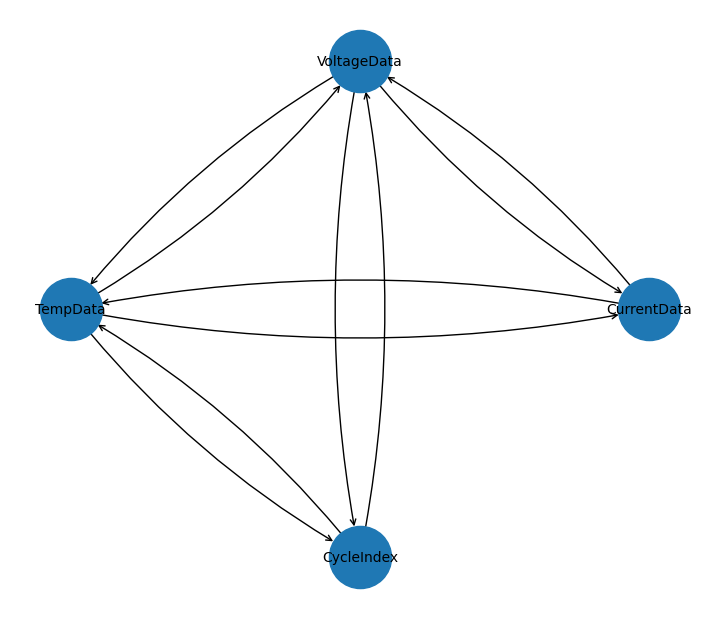

In [13]:
save_graph_plot(cols, dag_pc) 

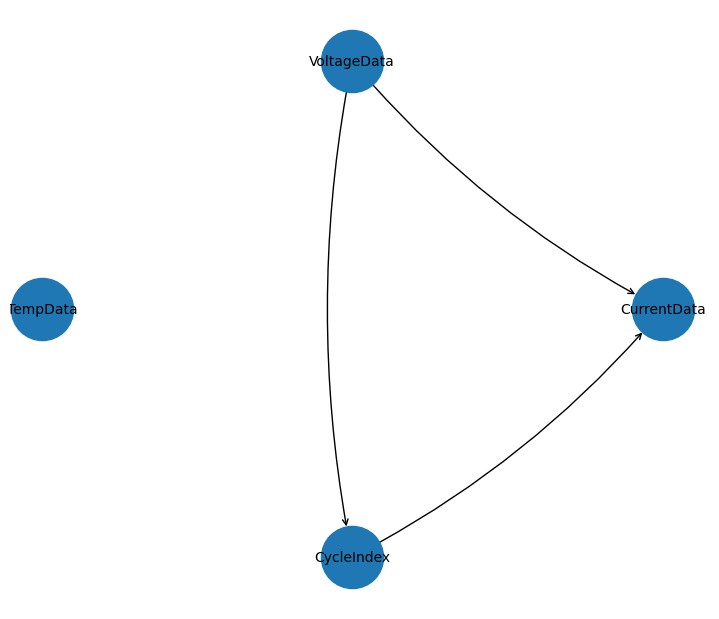

In [14]:
save_graph_plot(cols, dag_notears) 

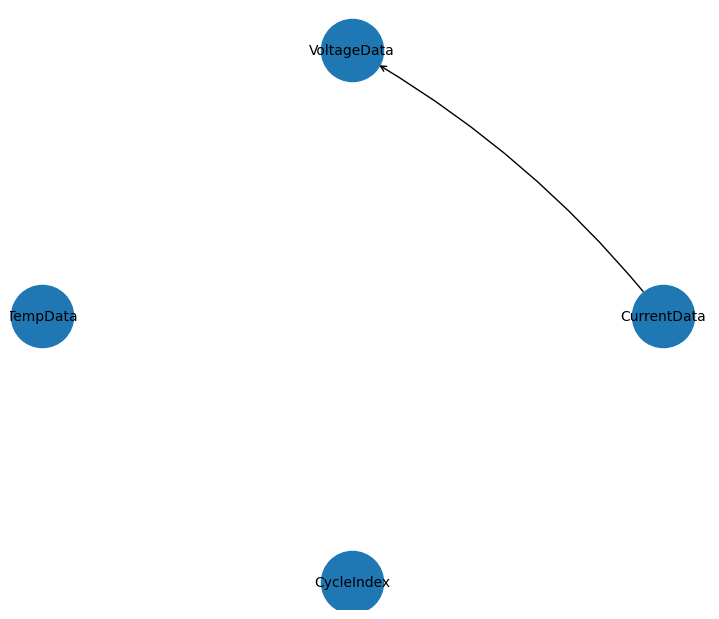

In [15]:
save_graph_plot(cols, dag_dotears) 